In [1]:
import sys

In [2]:
import mlx.core as mx
import mlx

In [3]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

 cupy not imported 
2.2.1


In [4]:
print(mx.metal.is_available())

True


In [5]:
scale=3
freqS=2.1*scale
freqL=3.4*scale

In [6]:
N = 64
mult = 2*200
span = 2
x = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
y = mx.sin(freqS*1*np.pi*x[:,0])*mx.sin(freqL*1*np.pi*x[:,1])
xt = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
yt = mx.sin(freqS*1*np.pi*xt[:,0])*mx.sin(freqL*1*np.pi*xt[:,1])
xtt = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
ytt = mx.sin(freqS*1*np.pi*xtt[:,0])*mx.sin(freqL*1*np.pi*xtt[:,1])
xttt = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
yttt = mx.sin(freqS*1*np.pi*xttt[:,0])*mx.sin(freqL*1*np.pi*xttt[:,1])
xtttt = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
ytttt = mx.sin(freqS*1*np.pi*xtttt[:,0])*mx.sin(freqL*1*np.pi*xtttt[:,1])
xttttt = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
yttttt = mx.sin(freqS*1*np.pi*xttttt[:,0])*mx.sin(freqL*1*np.pi*xttttt[:,1])
xv = (mx.random.uniform(low=0,high=1,shape=[mult*N],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0
yv = mx.sin(freqS*1*np.pi*xv[:,0])*mx.sin(freqL*1*np.pi*xv[:,1])

In [7]:
print(x.shape)
print(x[:10,:])

(12800, 2)
array([[0.151367, 0.792969],
       [0.354492, 0.0634766],
       [0.117188, -0.272949],
       ...,
       [0.546875, 0.770508],
       [0.632812, -0.435547],
       [-0.508789, 0.333984]], dtype=float16)


In [8]:
f = (mx.random.uniform(low=0,high=1,shape=[1024*2*160],dtype=mx.float16).reshape(-1,2)*2-1)*span/2.0 * 12

In [9]:
print(f.shape)
print(f[:10,:])
V=span*span

(163840, 2)
array([[5.95312, -0.263672],
       [-4.58203, -2.36719],
       [1.20703, -0.287109],
       ...,
       [6.55078, 6.52734],
       [4.44141, 6.19922],
       [-11.8828, -8.00781]], dtype=float16)


def mlx_nu_dft(x: mx.array, y: mx.array, f: mx.array, GROUP_SIZE: int = 1024) -> mx.array, mx.array:
    '''Directly computes in the DFT for non-uniformly sampled inputs                                                                                                                                        
       and non-uniformly sampled frequency vectors                                                                                                                                                          
                                                                                                                                                                                                            
       The computation complexity is of order NxdxM, and is intended for sparse                                                                                                                             
       collections of input and output samples in large d cases.                                                                                                                                            
                                                                                                                                                                                                            
       Args:                                                                                                                                                                                                
            x: Nxd array of arbitrary input vectors, each row being a vector of                                                                                                                             
               dimension d                                                                                                                                                                                  
            y: Nx1 array of function values at x                                                                                                                                                            
            f: A Mxd array of arbitrary frequency vectors                                                                                                                                                   
       Returns:                                                                                                                                                                                             
            Mx1 array representing the DFT of the function                                                                                                                                                  
                                                                                                                                                                                                            
    '''
    if (len(y.shape)==1): # common mistake                                                                                                                                                                  
        y = y.reshape(y.shape[0],1)

    w = mx.transpose(-2.0*np.pi*f)
    
    N = x.shape[0]
    M = f.shape[0]//GROUP_SIZE

    yfr = mx.zeros((f.shape[0],1),dtype=mx.float16)
    yfi = mx.zeros((f.shape[0],1),dtype=mx.float16)
    print(yfr.shape,M,w.shape)

    
    for i in range(M):
        tmp = mx.matmul(x,w[:,i*GROUP_SIZE:(i+1)*GROUP_SIZE],stream=mx.gpu).squeeze()
        #wq, s, b = mx.quantize(f[i*GROUP_SIZE:(i+1)*GROUP_SIZE,:],group_size=GROUP_SIZE//8,bits=8)
        #tmp1 = -2.0*np.pi*mx.quantized_matmul(x,wq,scales=s,biases=b,transpose=True,group_size=GROUP_SIZE//8,bits=8)
        #print('second ')
        #print(wq,wq.shape,s,s.shape,b,b.shape)
        #print('difference ',mx.add(tmp.squeeze(),-tmp1.squeeze()))
        #print('normal mx ',tmp,tmp.shape)
        #print('quantized mx ',tmp1,tmp1.shape)        
        yfr[i*GROUP_SIZE:(i+1)*GROUP_SIZE,0] = mx.sum(y*mx.cos(tmp,stream=mx.gpu),axis=0,stream=mx.gpu)
        yfi[i*GROUP_SIZE:(i+1)*GROUP_SIZE,0] = mx.sum(y*mx.sin(tmp,stream=mx.gpu),axis=0,stream=mx.gpu)
    i = M
    ii = f.shape[0]
    if ii>i*GROUP_SIZE:
        #wq, s, b = mx.quantize(f[i*GROUP_SIZE:ii,:],group_size=GROUP_SIZE//8,bits=8)
        #tmp1 = -2.0*np.pi*mx.quantized_matmul(x,wq,scales=s,biases=b,transpose=True,group_size=GROUP_SIZE//8,bits=8)
        tmp = mx.matmul(x,w[:,i*GROUP_SIZE:ii],stream=mx.gpu).squeeze()
        #print('final ')
        #print(wq,s,b)
        #print(mx.add(tmp,-tmp1.reshape(-1,GROUP_SIZE)))
        #print(tmp,tmp.shape)
        #print(tmp1,tmp1.shape)
        yfr[i*GROUP_SIZE:,0] = mx.sum(y*mx.cos(tmp,stream=mx.gpu),axis=0,stream=mx.gpu)
        yfi[i*GROUP_SIZE:,0] = mx.sum(y*mx.sin(tmp,stream=mx.gpu),axis=0,stream=mx.gpu)    
    
    return yfr,yfi


In [10]:
compiled_mlx_nu_dft = mx.compile(dft.mlx_nu_dft)

In [11]:
start = time.time()
yfr, yfi = dft.mlx_nu_dft(x,y,f)
print(time.time()-start)


0.00545501708984375


In [12]:
start = time.time()
yfr, yfi = compiled_mlx_nu_dft(x,y,f)
print(time.time()-start)

0.009123802185058594


In [13]:
start = time.time()
yf_old = dft.nu_dft(np.array(x,dtype=np.float32),np.array(y,dtype=np.float32),np.array(f,dtype=np.float32))
print(time.time()-start)


54.78121280670166


In [14]:
print(yfi.shape)
print(yfi)
print(np.imag(yf_old))
print(yfr)

(163840, 1)
array([[-8.03125],
       [-33.1875],
       [-66.1875],
       ...,
       [-38.0312],
       [-21.4375],
       [90.875]], dtype=float16)
[[ -7.7394543]
 [-32.98791  ]
 [-66.114876 ]
 ...
 [-38.0301   ]
 [-21.339134 ]
 [ 91.496765 ]]
array([[7.17188],
       [0.0703125],
       [57.7188],
       ...,
       [54.6562],
       [0.4375],
       [-37.625]], dtype=float16)


(163840, 1)
[[  7.171875  -8.03125j]
 [  0.0703125-33.1875j ]
 [ 57.71875  -66.1875j ]
 ...
 [ 54.65625  -38.03125j]
 [  0.4375   -21.4375j ]
 [-37.625    +90.875j  ]]


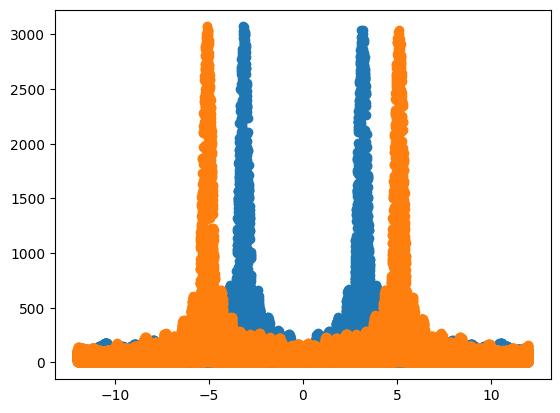

In [15]:
#yfr = np.array(yfr,dtype=np.float16)
#yfi = np.array(yfi,dtype=np.float16)
print(yfr.shape)
yf = np.array(yfr+1j*yfi,dtype=np.complex64)
print(yf)
plt.scatter(f[:,0],np.abs(yf))
plt.scatter(f[:,1],np.abs(yf))

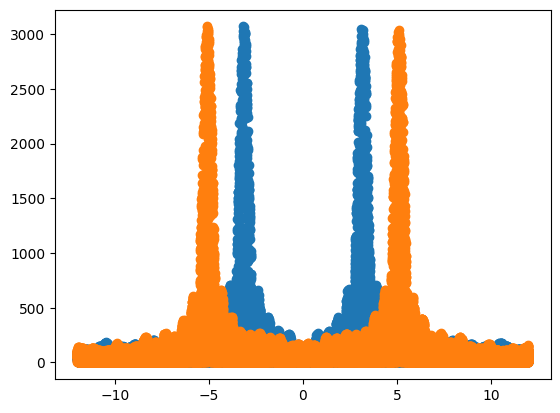

In [16]:
plt.scatter(f[:,0],np.abs(yf_old))
plt.scatter(f[:,1],np.abs(yf_old))

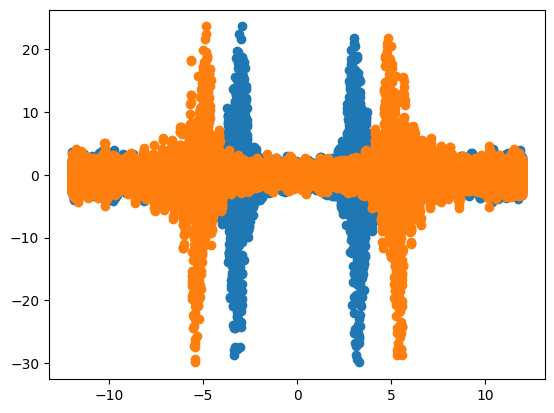

In [17]:
plt.scatter(f[:,0],np.abs(yf_old)-np.abs(yf))
plt.scatter(f[:,1],np.abs(yf_old)-np.abs(yf))

In [18]:
print(np.count_nonzero(~np.isnan(yfr)))
print(np.count_nonzero(np.isnan(yfr)))
print(np.count_nonzero(~np.isnan(yfi)))
print(np.count_nonzero(np.isnan(yfi)))
print(yfi.shape)

163840
0
163840
0
(163840, 1)


Pretty Clear